In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score,  roc_auc_score, roc_curve,precision_recall_curve,average_precision_score
from sklearn.preprocessing import label_binarize
from sklearn.utils import resample
from sklearn.metrics import confusion_matrix

Color legend
| Method | Color |
|---|---|
| kNN | blue |
| Logistic regression | red |
| Random forest | yellow |

In [2]:
KNN_COLOUR = "steelblue"
LR_COLOUR = "goldenrod"
RF_COLOUR = "forestgreen"

DATA LOADING

In [3]:
# CARICAMENTO DEL DATASET

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

# Leggi df_factors
df_factors = pd.read_csv("PDAC_DATA_MOFA_DATA/df_factors.csv", index_col=0)
print("df_factors caricato:")
print(df_factors.head())

# Leggi le matrici dei pesi per ogni vista
weights_per_view={
    "circRNA": None,
    "miRNA": None,
    "mRNA": None,
    "phosphoproteome": None,
    "proteome": None,
    "SCNA": None
}
for view_name in weights_per_view.keys():
    weights_per_view[view_name] = pd.read_csv(
        f"PDAC_DATA_MOFA_DATA/weights_{view_name}.csv",
        index_col=0
    )
    #print(f"\nPesi per {view_name} (prime righe):")
    #print(weights_per_view[view_name].head())

clinical_df= pd.read_csv("PDAC_DATA_PREPROCESSED/numerical_clinical.csv",index_col=0)   #clinical.csv

label_mapping_vs={0: "Living", 1: "Deceased"}
label_mapping_ts={1: "Stage I", 2: "Stage II", 3: "Stage III", 4: "Stage IV"}


df_factors caricato:
            Factor1   Factor2   Factor3   Factor4   Factor5   Factor6  \
case_id                                                                 
C3L-00017  3.772759 -0.024180 -0.039678  1.375110 -0.551716 -0.176812   
C3L-00102  1.362362 -0.283709  0.847602  3.748061 -1.124642  0.037608   
C3L-00189  2.768533 -1.336807  0.614068 -0.476359  1.154339  0.115143   
C3L-00277  1.526149  1.867423  1.530237  1.292304 -0.362401 -0.072971   
C3L-00401  3.035923  0.111856  0.122542  0.457961 -0.341562 -0.069621   

            Factor7   Factor8   Factor9  Factor10  Factor11  Factor12  \
case_id                                                                 
C3L-00017  0.165779 -0.112902  1.244698 -0.197673 -0.659694  0.129649   
C3L-00102  0.609494 -0.072042 -0.812959 -0.028058  0.364193  0.017682   
C3L-00189  0.248770 -0.084077 -0.418311 -0.135630 -0.080273 -0.006149   
C3L-00277 -0.124941 -0.226568  0.509663 -0.446523 -0.404787 -0.060446   
C3L-00401  0.115786 -0.087630

CLASSIFICATION (VITAL_STATUS)

In [4]:
# DEFINIZIONE DEI VARI GRAFICI

# ===================== Random Forest =====================
def plot_rf_feature_importance(fi: pd.Series):
    fi_sorted = fi.sort_values(ascending=False)
    
    plt.figure(figsize=(10, max(4, len(fi) * 0.3)))
    fi_sorted[::-1].plot(kind='barh', color=RF_COLOUR)
    plt.title('Random Forest Feature Importance')
    plt.xlabel('Gini Importance')
    plt.ylabel('Features')
    plt.tight_layout()
    plt.show()

# ===================== kNN =====================
def plot_knn_permutation_importance(fi: pd.Series):
    fi_sorted = fi.sort_values(ascending=False)
    
    plt.figure(figsize=(10, max(4, len(fi) * 0.3)))
    fi_sorted[::-1].plot(kind='barh', color=KNN_COLOUR)
    plt.title('kNN Permutation Importance')
    plt.xlabel('Decrease in performance')
    plt.ylabel('Features')
    plt.tight_layout()
    plt.show()

# ===================== Logistic Regression =====================
def plot_lr_coefficient_importance(fi: pd.Series):
    fi_sorted = fi.sort_values(ascending=False)
    
    plt.figure(figsize=(10, max(4, len(fi) * 0.3)))
    fi_sorted[::-1].plot(kind='barh', color=LR_COLOUR)
    plt.title('Logistic Regression Coefficient Importance')
    plt.xlabel('Coefficient')
    plt.ylabel('Features')
    plt.tight_layout()
    plt.show()


def plot_confusion_matrix(cm, model, model_name, label_mapping=None, colour="Blues"):
    
    # Recupera le classi nell'ordine corretto
    classes = model.classes_
    
    # Se fornita, mappa i valori numerici a stringhe
    if label_mapping is not None:
        class_labels = [label_mapping.get(c, str(c)) for c in classes]
    else:
        class_labels = classes

    # Plot
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap=colour,
        xticklabels=class_labels,
        yticklabels=class_labels
    )
    
    plt.title("Matrice di Confusione - " + model_name)
    plt.xlabel("Predetto")
    plt.ylabel("Vero")
    plt.tight_layout()
    plt.show()


def plot_classification_metrics(summary, colors:tuple):
    models = list(summary.keys())
    metrics = list(next(iter(summary.values())).keys())

    n_models = len(models)
    n_metrics = len(metrics)
    width = 0.2
    x = np.arange(n_metrics)

    plt.figure(figsize=(10, 6))

    for i, model in enumerate(models):
        values = [summary[model][m] for m in metrics]
        plt.bar(x + (i - n_models/2 + 0.5) * width, values, width=width, label=model, color=colors[i])

    plt.xticks(x, metrics)
    plt.ylim(0, 1)
    plt.ylabel("Score")
    plt.title("Riepilogo delle metriche di classificazione per modello")
    plt.legend()
    plt.tight_layout()
    plt.show()

def print_classification_metrics(summary):
    for model_name, summary in summary.items():
        print(f"\n=== {model_name} ===")
        for metric, value in summary.items():
            print(f"{metric}: {value:.4f}")

def select_best_model(summary, main_metric="AUPRC", verbose=True):
    metrics = list(next(iter(summary.values())).keys())

    # Miglior modello per ogni metrica
    best_models = {
        metric: max(
            summary.items(),
            key=lambda x: x[1][metric]
        )
        for metric in metrics
    }

    # Migliore in assoluto secondo la metrica principale
    best_model_name, best_model_info = best_models[main_metric]
    best_score = best_model_info[main_metric]

    if verbose:
        print("Riepilogo dei modelli migliori per ogni metrica:")
        for metric, (model_name, values) in best_models.items():
            print(f"Migliore per {metric}: {model_name} con {metric} = {values[metric]:.3f}")

        print(
            f"\nModello migliore in assoluto per {main_metric}: "
            f"{best_model_name} ({main_metric} = {best_score:.3f})"
        )

    return best_model_name

In [5]:
# DEFINIZIONE DEL GRAFICO PER LA VISUALIZZAZIONE DEI CONTRIBUTI DELLE SINGOLE FEATURE ALLE PREDIZIONI

# Per ogni vista:
#   calcola la media dei valori assoluti dei pesi per feature latente,
#   moltiplica ciascuna media per la feature importance della corrispondente feature latente,
#   somma tutti i risultati (contributo totale/assoluto della vista) e normalizza (contributo normalizzato).

def calculate_view_contributions(feature_importances, weights_per_view, model_name, colour="skyblue"):

    # 1. Ottieni l'importanza dei fattori latenti dal modello Random Forest
    #feature_importances = best_model.feature_importances_  # Importanza di ogni fattore latente

    # 2. Calcola il contributo di ogni vista ai fattori latenti
    # Per ogni vista, calcoliamo il contributo medio assoluto ai fattori latenti
    contributo_viste = {}
    for view_name, weights_df in weights_per_view.items():
        # Calcola il contributo medio assoluto della vista a ogni fattore latente
        contributo_vista = np.mean(np.abs(weights_df), axis=0)  # Media per colonna (fattore)
        contributo_viste[view_name] = contributo_vista

    # 3. Calcola il contributo totale di ogni vista alle predizioni
    contributo_totale = {}
    for view_name in contributo_viste.keys():
        # Moltiplica il contributo di ogni vista per l'importanza dei fattori latenti
        contributo_totale[view_name] = np.sum(contributo_viste[view_name] * feature_importances)

    # 4. Normalizza i contributi totali
    totale_contributi = sum(contributo_totale.values())
    contributo_normalizzato = {view: contrib / totale_contributi for view, contrib in contributo_totale.items()}

    # 5. Ordina le viste per contributo decrescente
    viste_ordinate = sorted(contributo_normalizzato.items(), key=lambda x: x[1], reverse=True)

    # 6. Visualizza i risultati (versione orizzontale corretta)
    plt.figure(figsize=(10, 6))

    # `viste_ordinate` è una lista di tuple (vista, contributo)
    viste, contributi = zip(*viste_ordinate)

    # Crea il grafico a barre orizzontali
    bars = plt.barh(viste, contributi, color=colour)

    # Aggiungi titoli e etichette
    plt.title(f"Contributo delle viste alle predizioni di {model_name}", fontsize=14)
    plt.xlabel("Contributo normalizzato", fontsize=12)
    plt.ylabel("Vista", fontsize=12)

    # Aggiungi i valori sulle barre
    for i, bar in enumerate(bars):
        width = bar.get_width()
        plt.text(width,  # Posizione x (all'estremità della barra)
                i,  # Posizione y (all'altezza della barra)
                f'{width:.2f}',
                ha='left',  # Allinea il testo a sinistra
                va='center',  # Allinea il testo verticalmente al centro
                fontsize=10)

    plt.tight_layout()
    plt.show()


    # 7. Stampa i contributi normalizzati
    print("\nContributo normalizzato delle viste alle predizioni:")
    for view, contrib in viste_ordinate:
        print(f"{view}: {contrib:.3f}")


In [6]:
#OVERSAMPLING della classe minoritaria (vital_status)

def oversample_minority(df, target_col, random_state=42):
    # Conta i valori per identificare la minoritaria e maggioritaria
    counts = df[target_col].value_counts()
    majority_class = counts.idxmax()
    minority_class = counts.idxmin()
    
    df_majority = df[df[target_col] == majority_class]
    df_minority = df[df[target_col] == minority_class]
    
    # Oversampling della minoritaria
    df_minority_upsampled = resample(
        df_minority,
        replace=True,
        n_samples=len(df_majority),
        random_state=random_state
    )
    
    # Combina e mischia
    df_balanced = pd.concat([df_majority, df_minority_upsampled])
    df_balanced = df_balanced.sample(frac=1, random_state=random_state).reset_index(drop=True)
    
    return df_balanced

# ======== Step 1: concatena fattori + target ========
df_combined_vs = pd.concat([df_factors, clinical_df['vital_status']], axis=1)

# ======== Step 2: train / test split ========
train_df, test_df = train_test_split(
    df_combined_vs,
    test_size=0.2,
    stratify=df_combined_vs['vital_status'],
    random_state=42
)

print("Distribuzione classe prima oversampling:")
print(train_df["vital_status"].value_counts())

# ======== Step 3: oversampling SOLO sul training set ========
train_df_balanced = oversample_minority(
    train_df,
    target_col='vital_status',
    random_state=42
)

print("Distribuzione classe dopo oversampling:")
print(train_df_balanced["vital_status"].value_counts())

# ======== Step 4: separa fattori e target ========
X_train = train_df_balanced.drop(columns=['vital_status'])
y_train = train_df_balanced['vital_status']

X_test = test_df.drop(columns=['vital_status'])
y_test = test_df['vital_status']


Distribuzione classe prima oversampling:
vital_status
1.0    61
0.0    48
Name: count, dtype: int64
Distribuzione classe dopo oversampling:
vital_status
1.0    61
0.0    61
Name: count, dtype: int64


In [7]:
# DEFINIZIONE DEI VARI ALGORITMI DI ADDESTRAMENTO (E TESTING)

# ===================== kNN =====================
def train_knn(X_train, X_test, y_train, y_test):

    model = KNeighborsClassifier(
        n_neighbors=5,
        weights="distance",
        n_jobs=-1
    )
    model.fit(X_train, y_train)

    # Permutation Importance
    result = permutation_importance(
        model, X_test, y_test, n_repeats=10, random_state=42, scoring="f1_weighted"
    )
    fi = pd.Series(result.importances_mean, index=X_train.columns)

    y_pred = model.predict(X_test)

    summary = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "F1_Weighted": f1_score(y_test, y_pred, average="weighted"),
        "Precision_Weighted": precision_score(y_test, y_pred, average="weighted"),
        "Recall_Weighted": recall_score(y_test, y_pred, average="weighted")
    }

    return model, fi, summary, y_pred


# ===================== Logistic Regression =====================
def train_logistic_regression(X_train, X_test, y_train, y_test):

    model = LogisticRegression(
        max_iter=1000,
        random_state=42,
    )
    model.fit(X_train, y_train)

    if model.coef_.shape[0] == 1:
        # CASO BINARIO: coef_ ha forma (1, n_features)
        fi = pd.Series(model.coef_[0], index=X_train.columns)
    else:
        # CASO MULTICLASSE: coef_ ha forma (n_classes, n_features)
        fi = pd.Series(np.abs(model.coef_).mean(axis=0), index=X_train.columns)

    y_pred = model.predict(X_test)

    summary = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "F1_Weighted": f1_score(y_test, y_pred, average="weighted"),
        "Precision_Weighted": precision_score(y_test, y_pred, average="weighted"),
        "Recall_Weighted": recall_score(y_test, y_pred, average="weighted")
    }

    return model, fi, summary, y_pred


# ===================== Random Forest =====================
def train_random_forest(X_train, X_test, y_train, y_test):

    model = RandomForestClassifier(
        n_estimators=500,
        random_state=42,
        n_jobs=-1
    )
    model.fit(X_train, y_train)

    fi = pd.Series(model.feature_importances_, index=X_train.columns)

    y_pred = model.predict(X_test)

    summary = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "F1_Weighted": f1_score(y_test, y_pred, average="weighted"),
        "Precision_Weighted": precision_score(y_test, y_pred, average="weighted"),
        "Recall_Weighted": recall_score(y_test, y_pred, average="weighted")
    }

    return model, fi, summary, y_pred

In [8]:
# ===================== Valutazione ROC e PRC classificatori binari (definizione funzione) =====================

def evaluate_binary_classifier(model, X_test, y_test, model_name="Model", colour="blue"):
    # Score probabilistico
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
    else:
        y_score = model.decision_function(X_test)

    # Metriche weighted
    auroc = roc_auc_score(y_test, y_score)  # AUROC binary non ha average
    auprc = average_precision_score(y_test, y_score)  # AUPRC binary non ha average

    # Curve
    fpr, tpr, _ = roc_curve(y_test, y_score)
    precision, recall, _ = precision_recall_curve(y_test, y_score)

    # Baseline PRC (classificatore casuale)
    positive_ratio = np.sum(y_test) / len(y_test)

    # Plot
    fig, ax = plt.subplots(1, 2, figsize=(12, 5))

    # ROC
    ax[0].plot(fpr, tpr, lw=2, label=f"ROC curve (AUROC={auroc:.3f})", color=colour)
    ax[0].plot([0, 1], [0, 1], color='lightgray', lw=2, linestyle=':', label="Random Classifier (AUROC=0.5)")
    ax[0].set_title(f"ROC - {model_name}")
    ax[0].set_xlabel("FPR")
    ax[0].set_ylabel("TPR")
    ax[0].legend()

    # PRC
    ax[1].plot(recall, precision, lw=2, label=f"PRC curve (AUPRC={auprc:.3f})", color=colour)
    ax[1].hlines(y=positive_ratio, xmin=0, xmax=1, color='lightgray', lw=2, linestyle=':', 
                 label=f"Random Classifier (AUPRC={positive_ratio:.3f})")
    ax[1].set_title(f"PRC - {model_name}")
    ax[1].set_xlabel("Recall")
    ax[1].set_ylabel("Precision")
    ax[1].legend()

    plt.tight_layout(w_pad=5)
    plt.show()

    return auroc, auprc

In [9]:
# ===================== Esecuzione classificazione vital_status =====================


knn_model, knn_fi, knn_summary, knn_y_pred = train_knn(X_train, X_test, y_train, y_test)
lr_model, lr_fi, lr_summary, lr_y_pred = train_logistic_regression(X_train, X_test, y_train, y_test)
best_model, rf_fi, rf_summary, rf_y_pred = train_random_forest(X_train, X_test, y_train, y_test)

training_results_vs = {
    "kNN": (knn_model, knn_fi, knn_summary, knn_y_pred, KNN_COLOUR),
    "Logistic Regression": (lr_model, lr_fi, lr_summary, lr_y_pred, LR_COLOUR),
    "Random Forest": (best_model, rf_fi, rf_summary, rf_y_pred, RF_COLOUR)
}

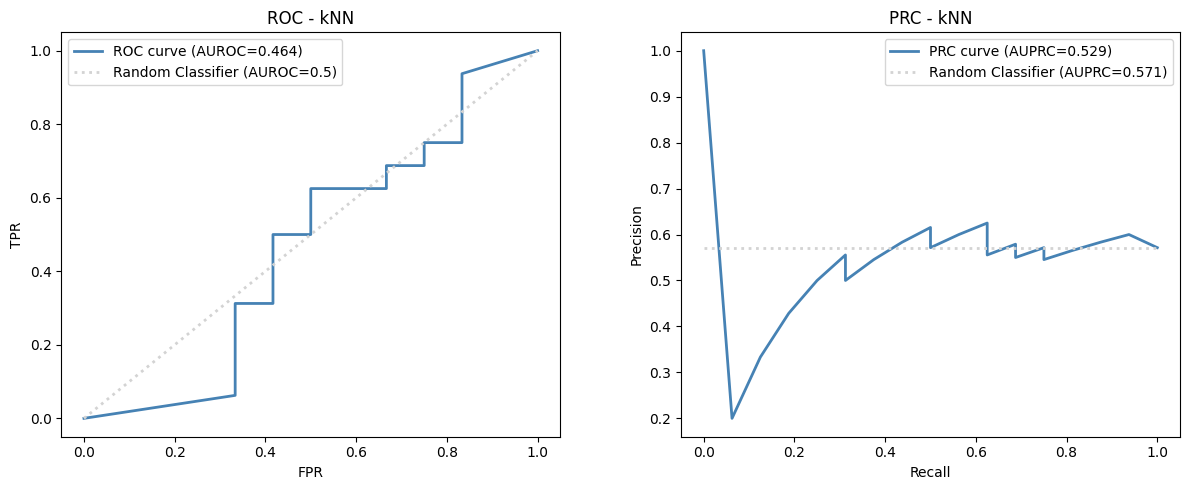

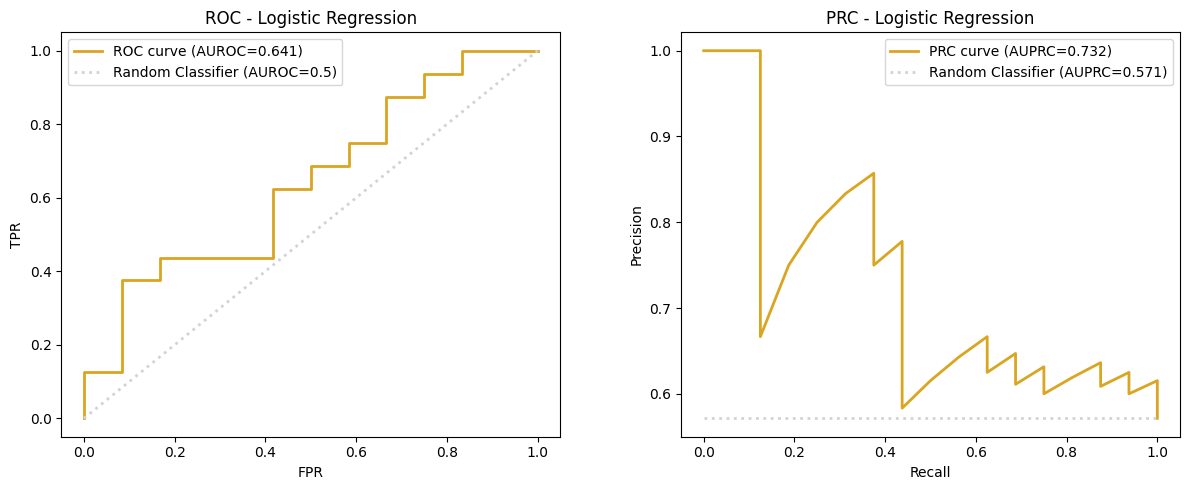

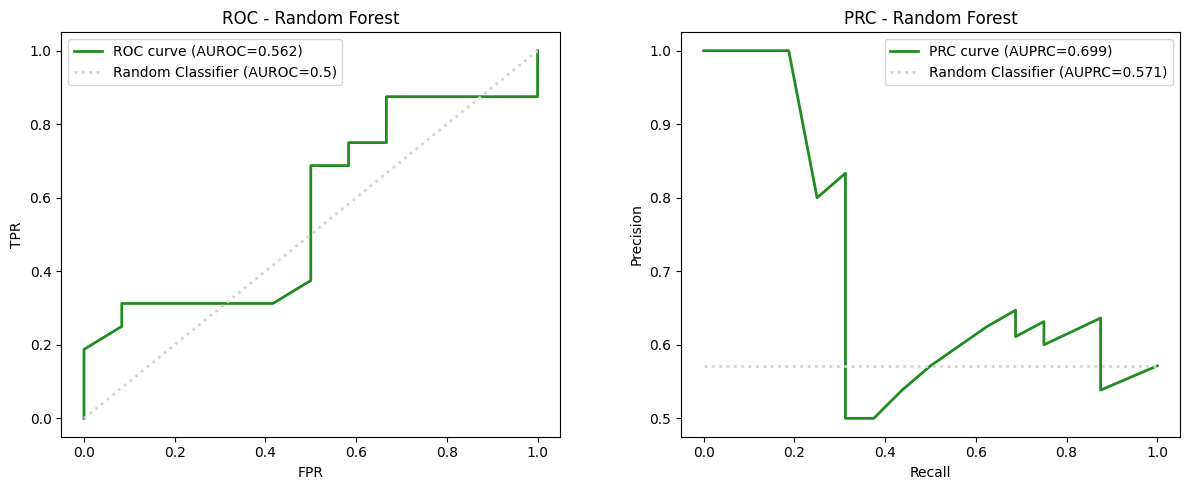

In [10]:
# ===================== Valutazione ROC e PRC classificatori binari =====================

for model_name, values in training_results_vs.items():
    model, fi, summary, y_pred, colour = values

    auroc, auprc = evaluate_binary_classifier(
        model,
        X_test,
        y_test,
        model_name=model_name,
        colour=colour
    )

    # aggiorno il dizionario aggiungendo le metriche
    training_results_vs[model_name][2]["AUROC"] = auroc
    training_results_vs[model_name][2]["AUPRC"] = auprc


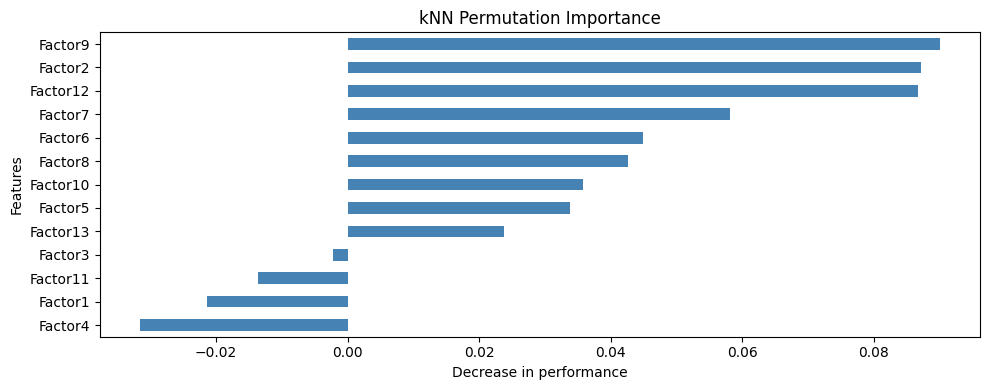

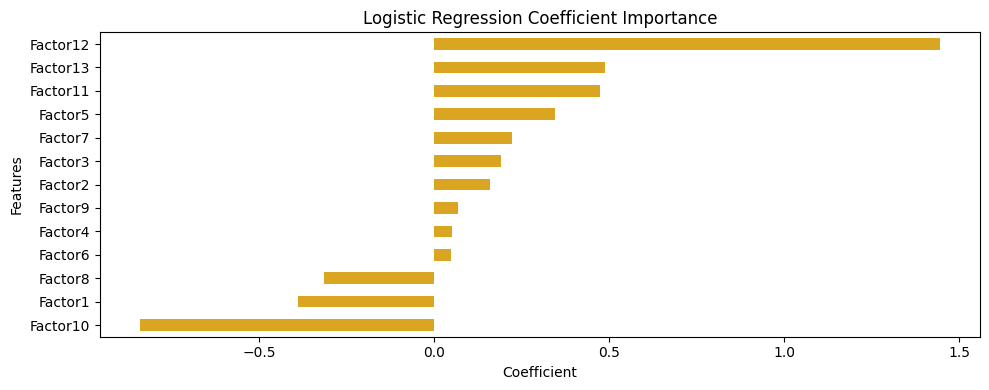

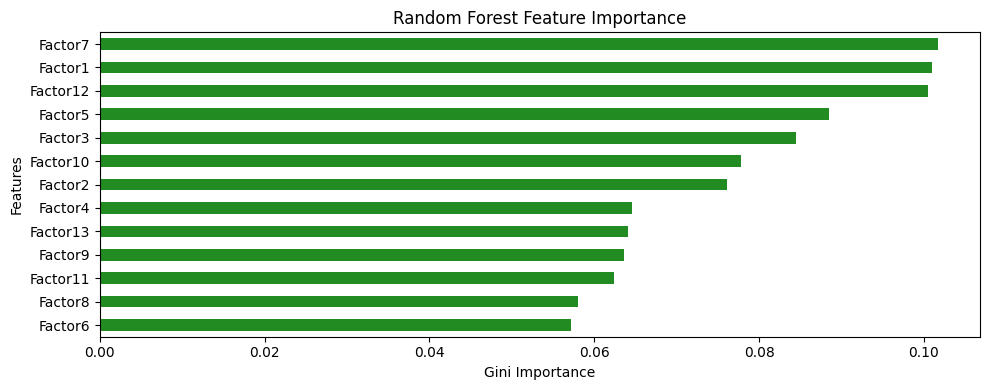

In [11]:
# ======== Visualizzazione FEATURE IMPORTANCE ========

plot_knn_permutation_importance(knn_fi)
plot_lr_coefficient_importance(lr_fi)
plot_rf_feature_importance(rf_fi)

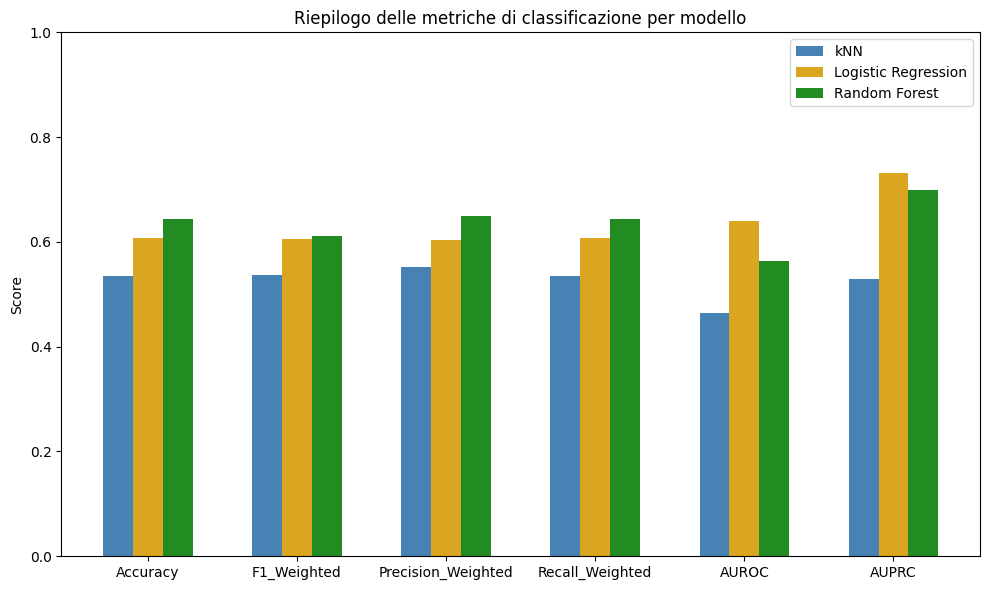


=== kNN ===
Accuracy: 0.5357
F1_Weighted: 0.5375
Precision_Weighted: 0.5516
Recall_Weighted: 0.5357
AUROC: 0.4635
AUPRC: 0.5286

=== Logistic Regression ===
Accuracy: 0.6071
F1_Weighted: 0.6046
Precision_Weighted: 0.6035
Recall_Weighted: 0.6071
AUROC: 0.6406
AUPRC: 0.7323

=== Random Forest ===
Accuracy: 0.6429
F1_Weighted: 0.6115
Precision_Weighted: 0.6494
Recall_Weighted: 0.6429
AUROC: 0.5625
AUPRC: 0.6992


In [12]:
# Riepilogo metriche di classificazione

model_summaries = {
    "kNN": knn_summary,
    "Logistic Regression": lr_summary,
    "Random Forest": rf_summary
}

plot_classification_metrics(model_summaries, (KNN_COLOUR, LR_COLOUR, RF_COLOUR))
print_classification_metrics(model_summaries)


Riepilogo dei modelli migliori per ogni metrica:
Migliore per Accuracy: Random Forest con Accuracy = 0.643
Migliore per F1_Weighted: Random Forest con F1_Weighted = 0.612
Migliore per Precision_Weighted: Random Forest con Precision_Weighted = 0.649
Migliore per Recall_Weighted: Random Forest con Recall_Weighted = 0.643
Migliore per AUROC: Logistic Regression con AUROC = 0.641
Migliore per AUPRC: Logistic Regression con AUPRC = 0.732

Modello migliore in assoluto per AUPRC: Logistic Regression (AUPRC = 0.732)


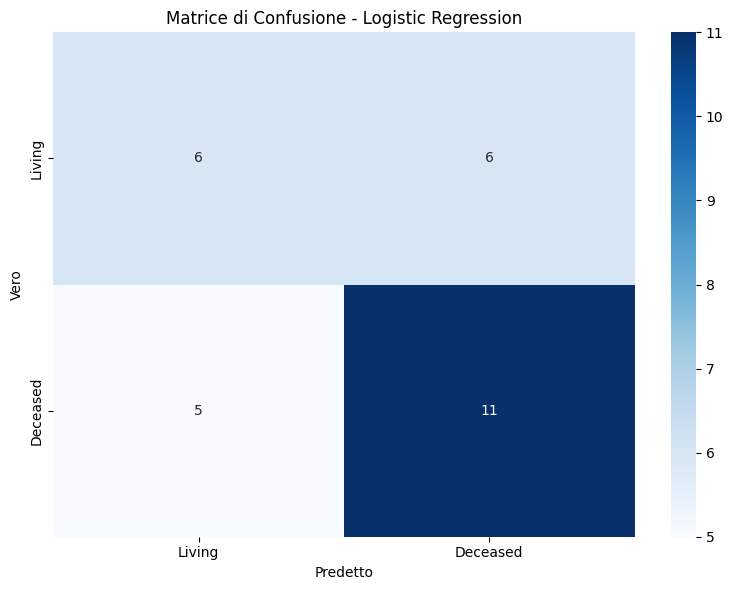

In [13]:
# DEFINIZIONE DEL MODELLO MIGLIORE

best_model_name=select_best_model(model_summaries)
best_model_y_pred=training_results_vs[best_model_name][3]
best_model=training_results_vs[best_model_name][0]

best_model_cm = confusion_matrix(y_test, best_model_y_pred)

plot_confusion_matrix(best_model_cm, best_model, best_model_name, label_mapping_vs, "Blues")

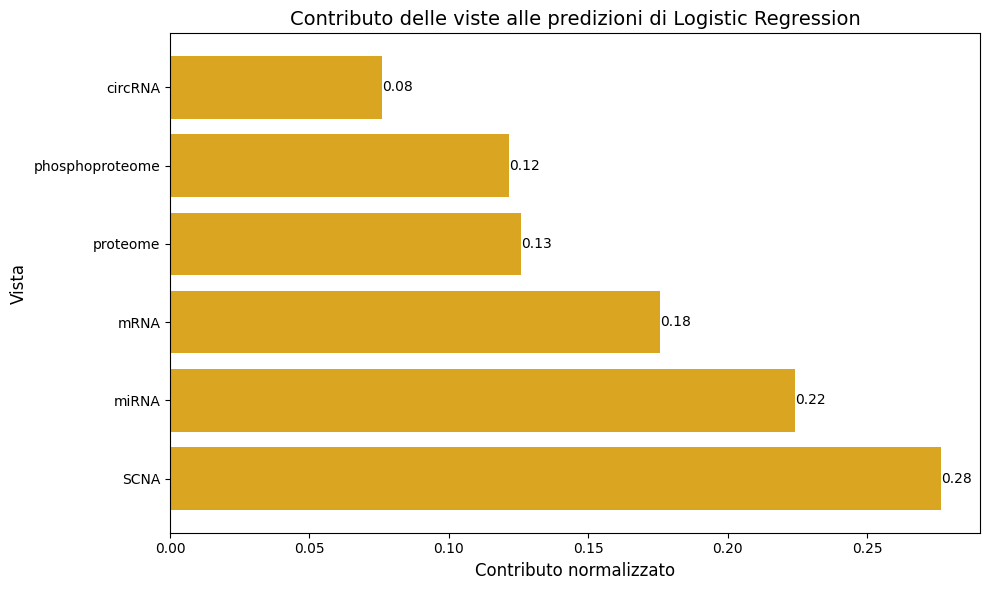


Contributo normalizzato delle viste alle predizioni:
SCNA: 0.277
miRNA: 0.224
mRNA: 0.176
proteome: 0.126
phosphoproteome: 0.122
circRNA: 0.076


In [14]:
# CALCOLO DEI CONTRIBUTI DELLE VISTE ALLE PREDIZIONI DEL MODELLO MIGLIORE

importances=training_results_vs[best_model_name][1]
calculate_view_contributions(importances, weights_per_view, best_model_name, LR_COLOUR)

CLASSIFICATION (TUMOR_STAGE)

In [15]:
# OVERSAMPLING delle classi minoritarie (tumor_stage)

def oversample_multiclass(df, target_col, random_state=42):
    df_balanced = []

    counts = df[target_col].value_counts()
    max_count = counts.max()

    for cls, n in counts.items():
        df_cls = df[df[target_col] == cls]

        if n < max_count:
            df_cls = resample(
                df_cls,
                replace=True,
                n_samples=max_count,
                random_state=random_state
            )

        df_balanced.append(df_cls)

    df_balanced = pd.concat(df_balanced)
    df_balanced = df_balanced.sample(frac=1, random_state=random_state)

    return df_balanced

# ======== Step 1: concatena fattori + target ========
df_combined_ts = pd.concat([df_factors, clinical_df['tumor_stage_numerical']], axis=1)

# ======== Step 2: train / test split ========
train_df, test_df = train_test_split(
    df_combined_ts,
    test_size=0.2,
    stratify=df_combined_ts['tumor_stage_numerical'],
    random_state=42
)

print("Distribuzione classe prima oversampling:")
print(train_df["tumor_stage_numerical"].value_counts())

# ======== Step 3: oversampling SOLO sul training set ========
train_df_balanced = oversample_multiclass(
    train_df,
    target_col='tumor_stage_numerical',
    random_state=42
)

print("Distribuzione classe dopo oversampling:")
print(train_df_balanced["tumor_stage_numerical"].value_counts())

# ======== Step 4: separa fattori e target ========
X_train = train_df_balanced.drop(columns=['tumor_stage_numerical'])
y_train = train_df_balanced['tumor_stage_numerical']

X_test = test_df.drop(columns=['tumor_stage_numerical'])
y_test = test_df['tumor_stage_numerical']

Distribuzione classe prima oversampling:
tumor_stage_numerical
2.0    52
3.0    33
1.0    17
4.0     7
Name: count, dtype: int64
Distribuzione classe dopo oversampling:
tumor_stage_numerical
4.0    52
2.0    52
3.0    52
1.0    52
Name: count, dtype: int64


In [16]:
# ===================== Valutazione ROC e PRC classificatori multiclasse (definizione funzione) =====================

def evaluate_multiclass_classifier(model, X_test, y_test, label_mapping=None, model_name="Model"):

    classes = np.unique(y_test)
    n_classes = len(classes)

    # Score probabilistico
    y_score = model.predict_proba(X_test)

    # Binarizzazione delle label (OvR)
    y_test_bin = label_binarize(y_test, classes=classes)

    # Dizionari per curve
    fpr = dict()
    tpr = dict()
    precision = dict()
    recall = dict()

    # Lista delle classi valide
    valid_classes = []
    for i in range(n_classes):
        if y_test_bin[:, i].sum() == 0:
            continue
        valid_classes.append(i)
        fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        precision[i], recall[i], _ = precision_recall_curve(y_test_bin[:, i], y_score[:, i])

    # Metriche weighted
    auroc_weighted = roc_auc_score(
        y_test_bin[:, valid_classes], y_score[:, valid_classes],
        average="weighted", multi_class="ovr"
    )
    auprc_weighted = average_precision_score(
        y_test_bin[:, valid_classes], y_score[:, valid_classes],
        average="weighted"
    )

    '''
    # Interpolazione weighted-curve
    all_fpr = np.unique(np.concatenate([fpr[i] for i in valid_classes]))
    mean_tpr = np.zeros_like(all_fpr)
    for i in valid_classes:
        mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
    mean_tpr /= len(valid_classes)

    all_recall = np.unique(np.concatenate([recall[i] for i in valid_classes]))
    mean_precision = np.zeros_like(all_recall)
    for i in valid_classes:
        mean_precision += np.interp(all_recall[::-1], recall[i][::-1], precision[i][::-1])[::-1]
    mean_precision /= len(valid_classes)
    '''
    # 1. Calcolo dei pesi per ogni classe valida
    class_counts = [y_test_bin[:, i].sum() for i in valid_classes]
    total_samples = sum(class_counts)
    class_weights = {idx: count / total_samples for idx, count in zip(valid_classes, class_counts)}

    # 2. Interpolazione Weighted ROC
    all_fpr = np.unique(np.concatenate([fpr[i] for i in valid_classes]))
    mean_tpr = np.zeros_like(all_fpr)
    for i in valid_classes:
        # Moltiplico l'interpolazione per il peso della classe
        mean_tpr += np.interp(all_fpr, fpr[i], tpr[i]) * class_weights[i]
    # NOTA: Non serve dividere per len(valid_classes) perché la somma dei pesi è 1

    # 3. Interpolazione Weighted PRC
    all_recall = np.unique(np.concatenate([recall[i] for i in valid_classes]))
    mean_precision = np.zeros_like(all_recall)
    for i in valid_classes:
        # Moltiplico l'interpolazione per il peso della classe
        interpolated_precision = np.interp(all_recall[::-1], recall[i][::-1], precision[i][::-1])[::-1]
        mean_precision += interpolated_precision * class_weights[i]

    # Calcolo del classificatore casuale weighted
    baseline_random = y_test_bin[:, valid_classes].mean(axis=0).mean()

    # Plot ROC e PRC
    fig, ax = plt.subplots(1, 2, figsize=(14, 6))

    # Curve singole ROC
    for i in valid_classes:
        label_name = label_mapping[classes[i]] if label_mapping else f"Classe {classes[i]}"
        ax[0].plot(fpr[i], tpr[i], lw=1, alpha=0.7,
                   label=f"{label_name} (AUROC={roc_auc_score(y_test_bin[:, i], y_score[:, i]):.2f})")
    # Weighted ROC
    ax[0].plot(all_fpr, mean_tpr, color='black', lw=2, linestyle='--',
               label=f"Weighted Curve (AUROC={auroc_weighted:.3f})")
    # Random classifier ROC
    ax[0].plot([0, 1], [0, 1], color='lightgray', lw=2, linestyle=':', label="Random Classifier (AUROC=0.5)")
    ax[0].set_title(f"ROC - {model_name}")
    ax[0].set_xlabel("FPR")
    ax[0].set_ylabel("TPR")
    ax[0].legend()

    # Curve singole PRC
    for i in valid_classes:
        label_name = label_mapping[classes[i]] if label_mapping else f"Classe {classes[i]}"
        ax[1].plot(recall[i], precision[i], lw=1, alpha=0.7,
                   label=f"{label_name} (AUPRC={average_precision_score(y_test_bin[:, i], y_score[:, i]):.2f})")
    # Weighted PRC
    ax[1].plot(all_recall, mean_precision, color='black', lw=2, linestyle='--',
               label=f"Weighted Curve (AUPRC={auprc_weighted:.3f})")
    # Random classifier PRC (simile a ROC: tratteggio nero chiaro)
    ax[1].hlines(baseline_random, 0, 1, color='lightgray', lw=2, linestyle=':', 
                 label=f"Random Classifier (AUPRC={baseline_random:.3f})")

    ax[1].set_title(f"PRC - {model_name}")
    ax[1].set_xlabel("Recall")
    ax[1].set_ylabel("Precision")
    ax[1].legend()

    plt.tight_layout()
    plt.show()

    return auroc_weighted, auprc_weighted

In [17]:
# ESECUZIONE CLASSIFICAZIONE tumor_stage

knn_model, knn_fi, knn_summary, knn_y_pred = train_knn(X_train, X_test, y_train, y_test)
lr_model, lr_fi, lr_summary, lr_y_pred = train_logistic_regression(X_train, X_test, y_train, y_test)
best_model, rf_fi, rf_summary, rf_y_pred = train_random_forest(X_train, X_test, y_train, y_test)

training_results_ts = {
    "kNN": (knn_model, knn_fi, knn_summary, knn_y_pred),
    "Logistic Regression": (lr_model, lr_fi, lr_summary, lr_y_pred),
    "Random Forest": (best_model, rf_fi, rf_summary, rf_y_pred)
}

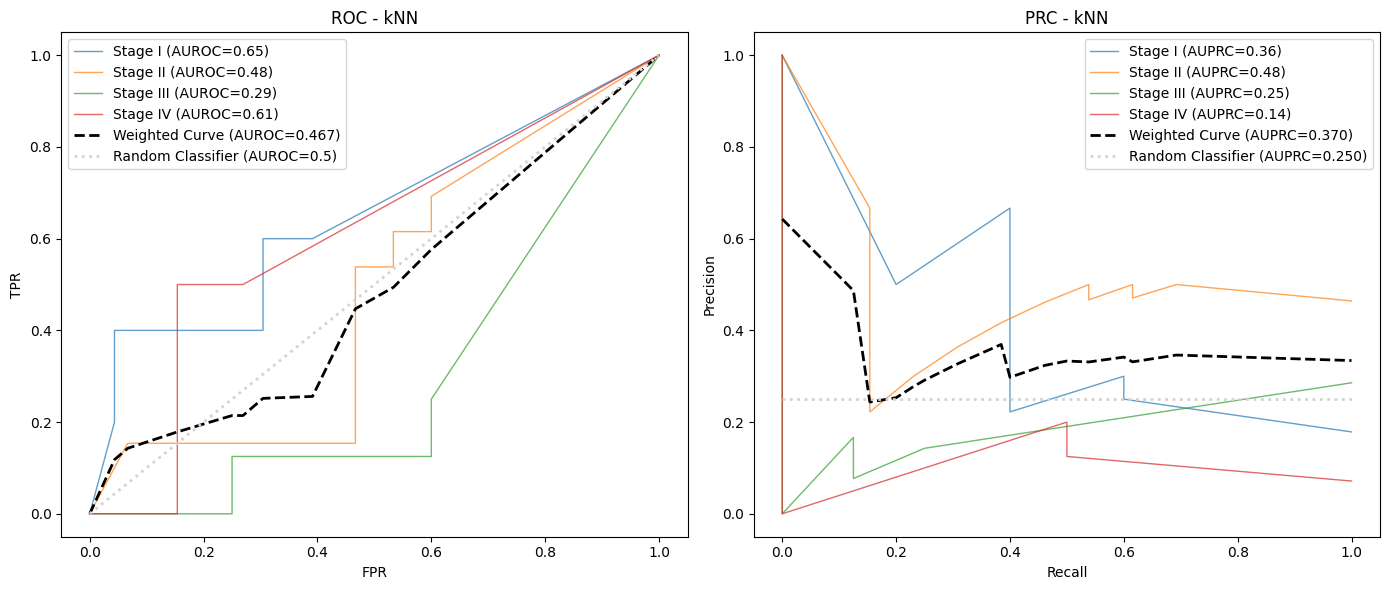

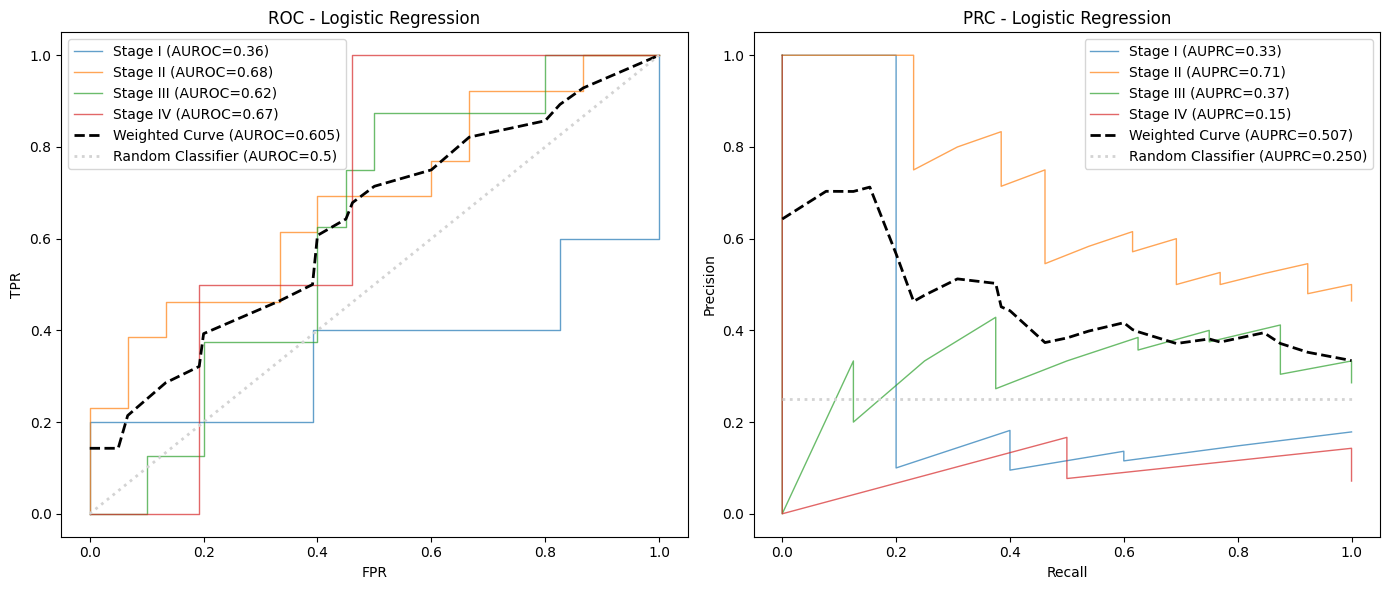

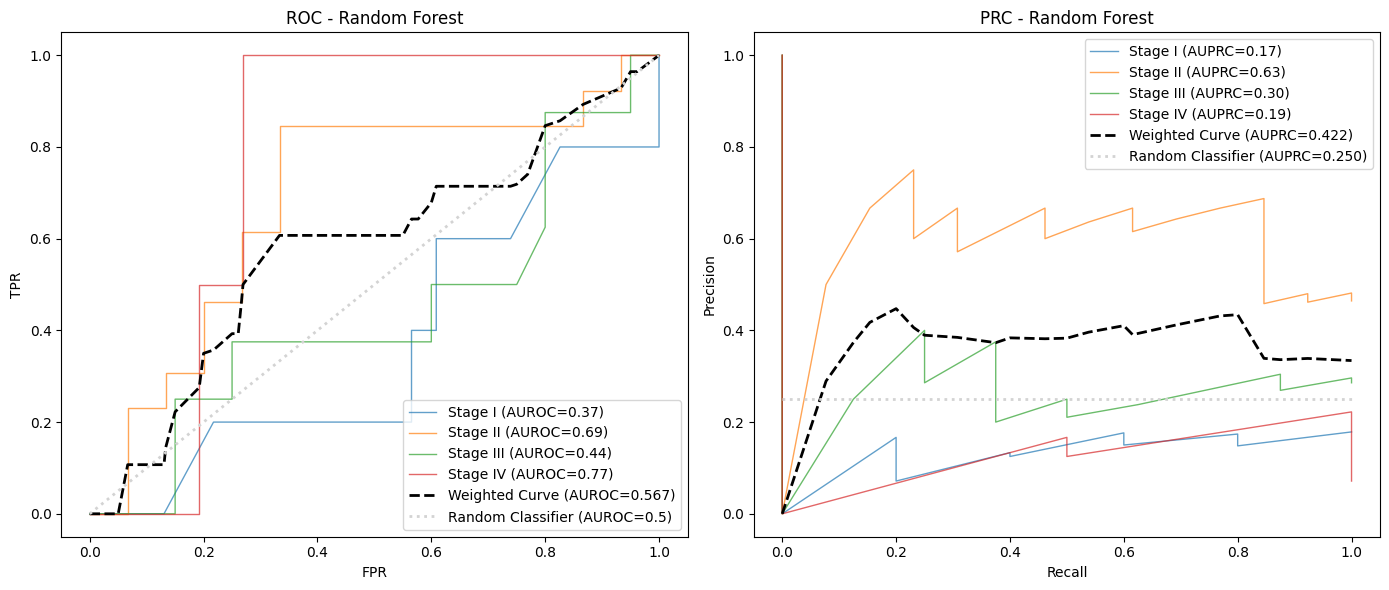

In [18]:
# ===================== Valutazione ROC e PRC classificatori multiclasse =====================

for model_name, values in training_results_ts.items():
    model, fi, summary, y_pred = values

    classes = np.unique(y_test)
    n_classes = len(classes)

    auroc, auprc = evaluate_multiclass_classifier(
        model,
        X_test,
        y_test,
        model_name=model_name,
        label_mapping=label_mapping_ts
    )

    training_results_ts[model_name][2]["AUROC"] = auroc
    training_results_ts[model_name][2]["AUPRC"] = auprc


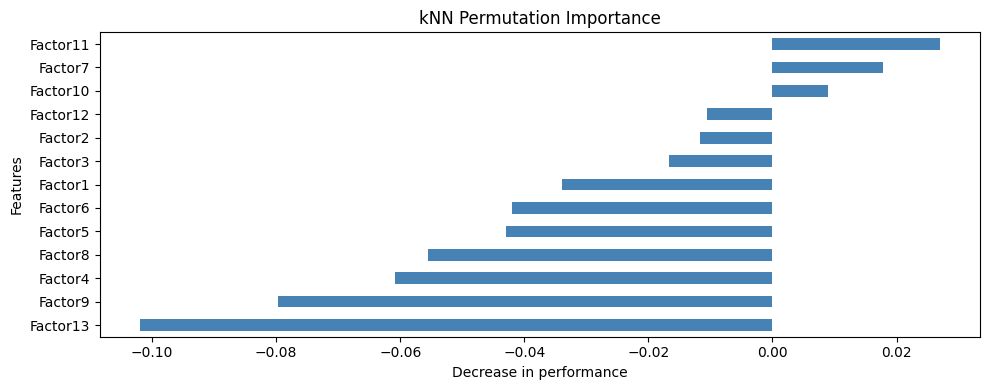

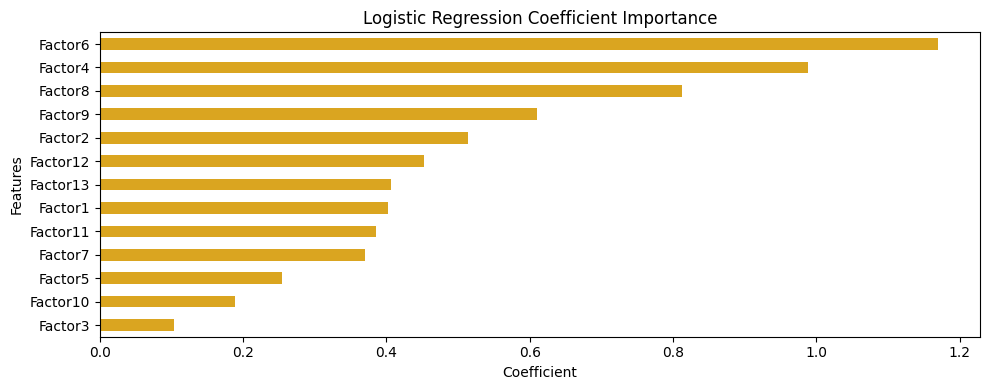

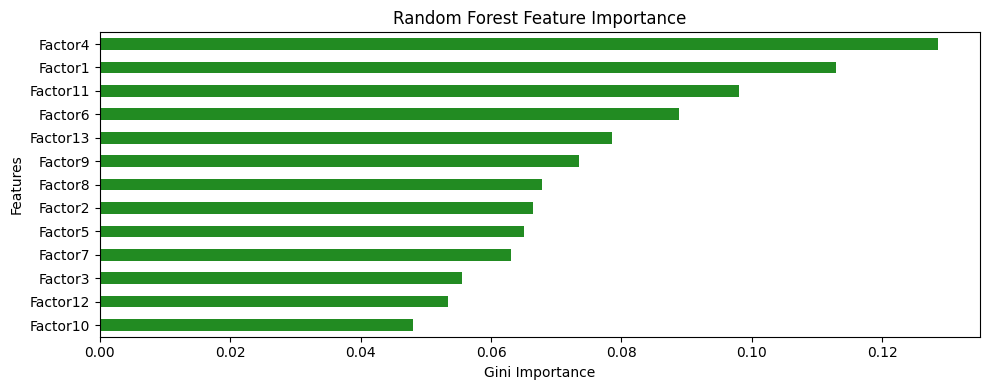

In [19]:
# ======== Visualizzazione feature/permutation importance ========

plot_knn_permutation_importance(knn_fi)
plot_lr_coefficient_importance(lr_fi)
plot_rf_feature_importance(rf_fi)

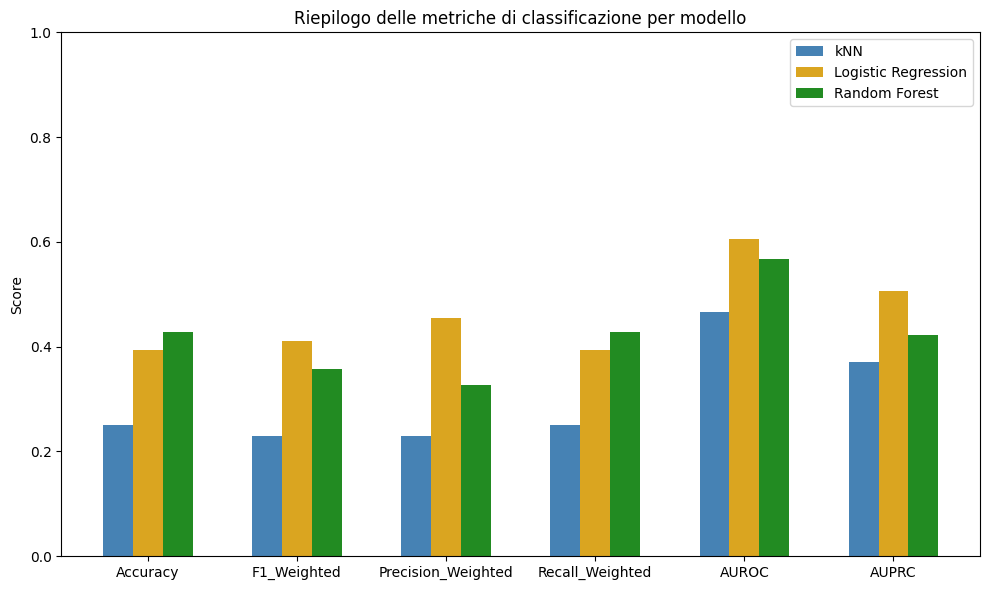


=== kNN ===
Accuracy: 0.2500
F1_Weighted: 0.2302
Precision_Weighted: 0.2301
Recall_Weighted: 0.2500
AUROC: 0.4667
AUPRC: 0.3697

=== Logistic Regression ===
Accuracy: 0.3929
F1_Weighted: 0.4099
Precision_Weighted: 0.4554
Recall_Weighted: 0.3929
AUROC: 0.6052
AUPRC: 0.5068

=== Random Forest ===
Accuracy: 0.4286
F1_Weighted: 0.3571
Precision_Weighted: 0.3268
Recall_Weighted: 0.4286
AUROC: 0.5667
AUPRC: 0.4219


In [20]:
# Riepilogo metriche di classificazione

# Dizionario dei summary per comodità
model_summaries = {
    "kNN": knn_summary,
    "Logistic Regression": lr_summary,
    "Random Forest": rf_summary
}

plot_classification_metrics(model_summaries, (KNN_COLOUR, LR_COLOUR, RF_COLOUR))
print_classification_metrics(model_summaries)

Riepilogo dei modelli migliori per ogni metrica:
Migliore per Accuracy: Random Forest con Accuracy = 0.429
Migliore per F1_Weighted: Logistic Regression con F1_Weighted = 0.410
Migliore per Precision_Weighted: Logistic Regression con Precision_Weighted = 0.455
Migliore per Recall_Weighted: Random Forest con Recall_Weighted = 0.429
Migliore per AUROC: Logistic Regression con AUROC = 0.605
Migliore per AUPRC: Logistic Regression con AUPRC = 0.507

Modello migliore in assoluto per AUPRC: Logistic Regression (AUPRC = 0.507)


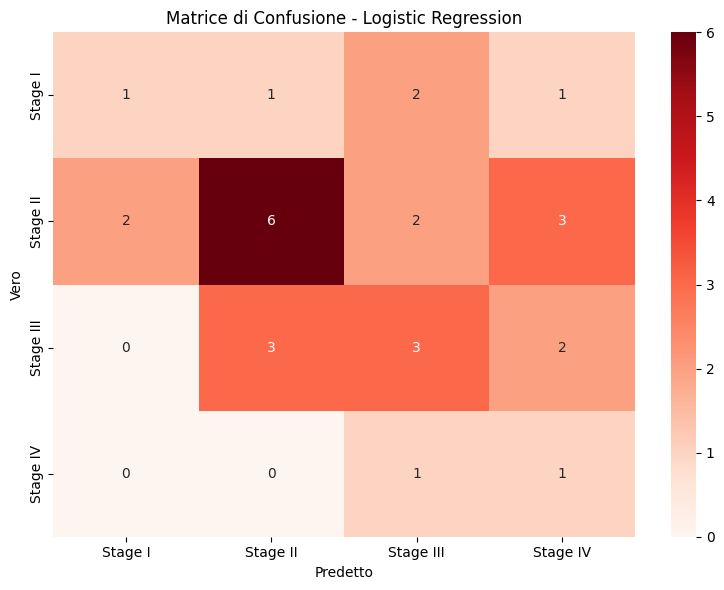

In [21]:
# DEFINIZIONE DEL MODELLO MIGLIORE
best_model_name=select_best_model(model_summaries)
best_model=training_results_ts[best_model_name][0]
best_model_y_pred=training_results_ts[best_model_name][3]

best_model_cm = confusion_matrix(y_test, best_model_y_pred)

plot_confusion_matrix(best_model_cm, best_model, best_model_name, label_mapping_ts, "Reds")

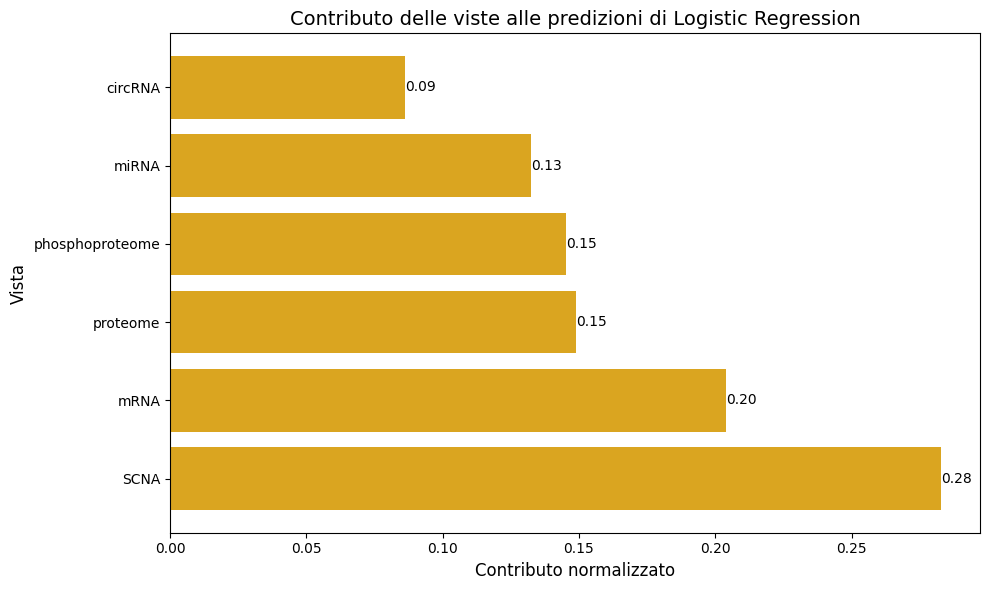


Contributo normalizzato delle viste alle predizioni:
SCNA: 0.283
mRNA: 0.204
proteome: 0.149
phosphoproteome: 0.145
miRNA: 0.132
circRNA: 0.086


In [22]:
# Calcolo e visualizzazione contributi delle viste

importances=training_results_ts[best_model_name][1]
calculate_view_contributions(importances, weights_per_view, best_model_name, LR_COLOUR)